### KMeans Clustering

In [10]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#making custom dataset
from sklearn.datasets import make_blobs

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans

In [4]:
x, y = make_blobs(n_samples=1000, n_features=2, centers=3, random_state=42)

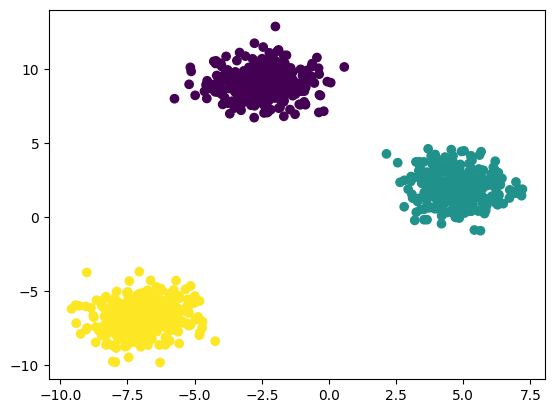

In [6]:
#visualization

plt.scatter(x[:, 0], x[:, 1], c=y)
plt.show()

In [8]:
#splitting into train and test sets

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [9]:
#standardization

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

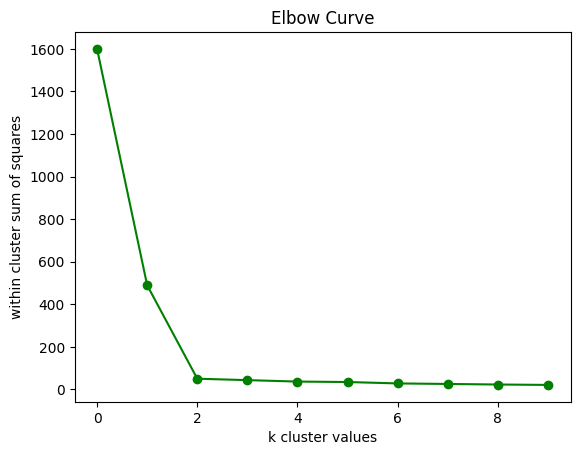

In [15]:
#applying KMeans clustering 
wcss = []
for n_clus in range(1,11):

    kmeans = KMeans(n_clusters=n_clus, init="k-means++")
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

plt.plot(wcss, marker='o', c='g')    
plt.title("Elbow Curve")
plt.xlabel("k cluster values")
plt.ylabel("within cluster sum of squares")
plt.show()

As per the elbow curve clusters between 2 - 4 gives less error.

In [25]:
#selecting n_clusters=3

kmeans = KMeans(n_clusters=3, init="k-means++")
pred=kmeans.fit_predict(x_test)
pred

array([0, 1, 1, 2, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0, 2, 1, 1, 2, 1, 2, 0, 0,
       1, 1, 0, 0, 2, 0, 0, 1, 0, 2, 2, 0, 2, 0, 0, 2, 2, 2, 0, 1, 1, 2,
       1, 0, 2, 1, 2, 0, 0, 1, 2, 0, 1, 1, 2, 2, 2, 1, 2, 2, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 2, 0, 2, 1, 2, 2, 2, 2, 0, 0, 2, 2, 1, 1, 1, 2, 0,
       1, 2, 1, 1, 0, 1, 2, 2, 1, 1, 2, 2, 1, 0, 2, 1, 0, 0, 1, 0, 2, 2,
       0, 2, 0, 0, 1, 0, 0, 1, 2, 2, 2, 0, 0, 0, 2, 1, 2, 2, 0, 0, 1, 2,
       2, 2, 1, 2, 2, 1, 1, 2, 0, 0, 1, 0, 1, 0, 2, 0, 1, 2, 1, 2, 2, 2,
       1, 2, 2, 0, 2, 0, 1, 0, 1, 2, 0, 0, 1, 0, 1, 2, 1, 0, 2, 2, 0, 1,
       0, 2, 0, 0, 2, 2, 2, 2, 2, 0, 1, 0, 1, 1, 0, 1, 1, 2, 1, 0, 2, 1,
       1, 2], dtype=int32)

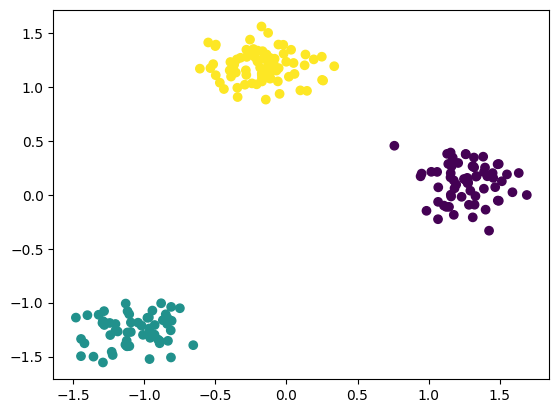

In [26]:
plt.scatter(x_test[:, 0], x_test[:, 1], c=pred)

To validate n_clusters value we can use below two methods:
* KneeLocator
* Silhouette Scoring